# Entrega 2 — Punto 2: Respuesta a las 8 preguntas de negocio

## Proyecto CodeCrew — Relación entre resultados ICFES Saber 11 y acceso a internet por municipio

**Curso:** Procesamiento de Datos a Gran Escala — Pontificia Universidad Javeriana — 2026  
**Metodología:** CRISP-DM — Fase 5 (Evaluación / análisis de negocio)  
**Autor de este notebook:** Sebastian Basto Rodriguez (spark-worker2)

---

### Propósito

Este notebook responde las **8 preguntas de negocio** definidas en la Entrega 1, usando como insumo las tablas limpias generadas por `transform_clean.py` (Punto 1) en `data/parquet_clean/`. Cada pregunta se resuelve con **agregaciones PySpark** y se acompaña de una **tabla de resultado** y, donde aporta, de una **visualización**.

### Tablas insumo (generadas en el Punto 1)

| Tabla | Contenido | Columnas clave |
|---|---|---|
| `icfes` | Resultados Saber 11 limpios | `punt_global`, 5 `punt_*` por área, `flag_internet_hogar`, `cole_naturaleza`, `cole_area_ubicacion`, `cod_municipio_norm`, `year_icfes` |
| `internet` | Accesos residenciales limpios | `no_de_accesos`, `velocidad_bajada`, `categoria_velocidad_bajada`, `tecnologia`, `cod_municipio_norm`, `year_int` |
| `bachillerato` | Cobertura educativa limpia | `cobertura_neta`, `deserci_n`, `sedes_conectadas_a_internet`, `poblaci_n_5_16`, `cod_municipio_norm` |
| `municipio_internet_cobertura` | Agregado municipio-año | `accesos_por_habitante`, `nivel_conectividad_municipio`, `total_accesos_internet`, `cobertura_neta` |

### Advertencias metodológicas (heredadas del Punto 1)

Estas decisiones del pipeline afectan la interpretación de varias preguntas y se mencionan en cada una donde aplica:

1. **Filtro IQR sobre `punt_global`:** los puntajes extremos (regla de Tukey 1.5×IQR) fueron eliminados. Los promedios de puntaje reflejan la población sin outliers.
2. **`punt_ingles` imputado por la media:** los nulos de inglés se rellenaron con el promedio. Esto **reduce artificialmente la varianza** de inglés; relevante en la Pregunta 7 (comparación de brechas por área).
3. **`accesos_por_habitante` solo con accesos residenciales:** el Filtro 2 excluyó el segmento corporativo. La métrica refleja conectividad doméstica, no total — es una redefinición deliberada respecto a la Entrega 1.
4. **Join por `cod_municipio_norm`:** ICFES e internet se cruzan por código DANE municipal normalizado a 5 dígitos. Municipios sin contraparte quedan con valores nulos (join `left`).

---
## 0. Sesión de Spark y carga de tablas

In [3]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F

spark = (
    SparkSession.builder
    .appName("Entrega2-Punto2-Preguntas-Negocio")
    .master("spark://spark-master:7077")
    .config("spark.executor.memory", "8g")
    .config("spark.executor.cores", "4")
    .config("spark.sql.codegen.wholeStage", "false")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("ERROR")

CLEAN = "hdfs://spark-master:9000/user/estudiante/data/parquet_clean"

icfes     = spark.read.parquet(f"{CLEAN}/icfes")
internet  = spark.read.parquet(f"{CLEAN}/internet")
bach      = spark.read.parquet(f"{CLEAN}/bachillerato")
municipio = spark.read.parquet(f"{CLEAN}/municipio_internet_cobertura")

# Cache: estas tablas se reutilizan en casi todas las preguntas.
icfes.cache(); municipio.cache()

print("Tablas cargadas desde", CLEAN)
print(f"  icfes     : {icfes.count():,} filas")
print(f"  internet  : {internet.count():,} filas")
print(f"  bachillerato: {bach.count():,} filas")
print(f"  municipio_internet_cobertura: {municipio.count():,} filas")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/21 19:02:50 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
                                                                                

Tablas cargadas desde hdfs://spark-master:9000/user/estudiante/data/parquet_clean


  icfes     : 7,087,868 filas
  internet  : 1,477,357 filas
  bachillerato: 15,707 filas
  municipio_internet_cobertura: 7,458 filas


In [4]:
for nombre, df in [("icfes", icfes), ("internet", internet),
                    ("bachillerato", bach), ("municipio", municipio)]:
    print(f"=== {nombre} ===")
    print(df.columns)
    print()

=== icfes ===
['punt_c_naturales', 'punt_global', 'punt_ingles', 'punt_lectura_critica', 'punt_matematicas', 'punt_sociales_ciudadanas', 'cole_cod_mcpio_ubicacion', 'periodo', 'estu_estadoinvestigacion', 'estu_privado_libertad', 'fami_tieneinternet', 'cole_area_ubicacion', 'cole_naturaleza', 'cod_municipio_norm', 'year_icfes', 'flag_internet_hogar']

=== internet ===
['no_de_accesos', 'velocidad_bajada', 'velocidad_subida', 'cod_municipio', 'anno', 'segmento', 'tecnologia', 'cod_municipio_norm', 'year_int', 'categoria_velocidad_bajada']

=== bachillerato ===
['cobertura_neta', 'cobertura_neta_primaria', 'cobertura_neta_secundaria', 'cobertura_neta_media', 'cobertura_bruta', 'deserci_n', 'deserci_n_primaria', 'deserci_n_secundaria', 'aprobaci_n', 'reprobaci_n', 'repitencia', 'sedes_conectadas_a_internet', 'tasa_matriculaci_n_5_16', 'poblaci_n_5_16', 'tama_o_promedio_de_grupo', 'c_digo_municipio', 'a_o', 'municipio', 'departamento', 'cod_municipio_norm', 'year_int']

=== municipio ===
['

In [5]:

try:
    import matplotlib
    %matplotlib inline
    import matplotlib.pyplot as plt
    PLOT_OK = True
    print("matplotlib disponible: se generaran graficos.")
except Exception as e:
    PLOT_OK = False
    print("matplotlib NO disponible -> solo tablas. Detalle:", e)
    print("Para habilitar graficos: pip install matplotlib dentro del venv.")

matplotlib disponible: se generaran graficos.


---
## Pregunta 1 — ¿Cómo se comparan los puntajes Saber 11 entre municipios con alta y baja cobertura de internet?

**Enfoque:** se cruza `icfes` con `municipio_internet_cobertura` por código DANE municipal. Cada estudiante hereda el `nivel_conectividad_municipio` (terciles de `accesos_por_habitante`) de su municipio. Se compara el `punt_global` promedio entre niveles `baja`, `media`, `alta`.

*Nota: `punt_global` ya está sin outliers (filtro IQR del Punto 1).*


In [6]:
# Nivel de conectividad por municipio (una fila por municipio-año).
muni_nivel = municipio.select(
    "cod_municipio_norm", "nivel_conectividad_municipio", "accesos_por_habitante"
)

icfes_p1 = icfes.join(muni_nivel, on="cod_municipio_norm", how="inner")

p1 = (
    icfes_p1
    .filter(F.col("nivel_conectividad_municipio").isNotNull())
    .groupBy("nivel_conectividad_municipio")
    .agg(
        F.count("*").alias("n_estudiantes"),
        F.round(F.avg("punt_global"), 2).alias("punt_global_prom"),
        F.round(F.stddev("punt_global"), 2).alias("punt_global_std"),
    )
    # Orden logico baja < media < alta
    .withColumn("_ord", F.when(F.col("nivel_conectividad_municipio") == "baja", 1)
                          .when(F.col("nivel_conectividad_municipio") == "media", 2)
                          .otherwise(3))
    .orderBy("_ord").drop("_ord")
)

print("PREGUNTA 1 — Puntaje global por nivel de conectividad del municipio")
p1.show(truncate=False)

PREGUNTA 1 — Puntaje global por nivel de conectividad del municipio


+----------------------------+-------------+----------------+---------------+
|nivel_conectividad_municipio|n_estudiantes|punt_global_prom|punt_global_std|
+----------------------------+-------------+----------------+---------------+
|baja                        |15473504     |249.43          |50.1           |
|media                       |17496499     |250.56          |49.23          |
|alta                        |15122490     |255.14          |49.03          |
+----------------------------+-------------+----------------+---------------+



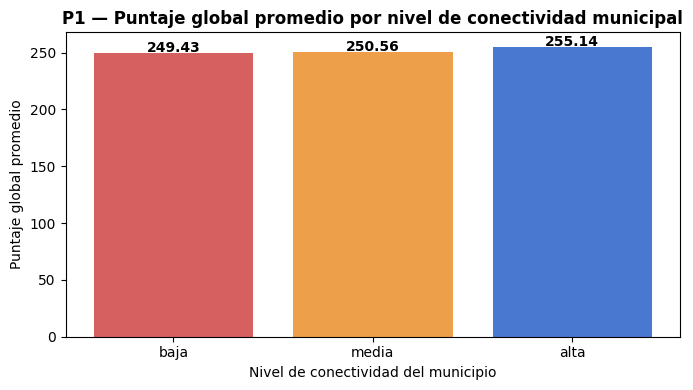

In [7]:
if PLOT_OK:
    d = p1.toPandas()
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(d["nivel_conectividad_municipio"], d["punt_global_prom"],
           color=["#D65F5F", "#EE9F4A", "#4878CF"])
    ax.set_title("P1 — Puntaje global promedio por nivel de conectividad municipal",
                 fontweight="bold")
    ax.set_xlabel("Nivel de conectividad del municipio")
    ax.set_ylabel("Puntaje global promedio")
    for i, v in enumerate(d["punt_global_prom"]):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## Pregunta 2 — ¿El internet en el hogar se asocia a mayor puntaje global?

**Enfoque:** se usa `flag_internet_hogar` (1 = hogar con internet, 0 = sin internet, null = no informado) directamente sobre `icfes`. Se comparan promedios y se calcula la **correlación de Pearson** entre el flag y `punt_global`.

In [8]:
p2 = (
    icfes
    .filter(F.col("flag_internet_hogar").isNotNull())
    .groupBy("flag_internet_hogar")
    .agg(
        F.count("*").alias("n_estudiantes"),
        F.round(F.avg("punt_global"), 2).alias("punt_global_prom"),
        F.round(F.avg("punt_matematicas"), 2).alias("punt_matematicas_prom"),
    )
    .orderBy("flag_internet_hogar")
)

print("PREGUNTA 2 — Puntaje segun internet en el hogar (0 = No, 1 = Si)")
p2.show(truncate=False)

# Correlacion de Pearson flag_internet_hogar <-> punt_global
corr = (
    icfes.filter(F.col("flag_internet_hogar").isNotNull() & F.col("punt_global").isNotNull())
         .stat.corr("flag_internet_hogar", "punt_global")
)
print(f"\nCorrelacion de Pearson (flag_internet_hogar, punt_global): {corr:.4f}")

PREGUNTA 2 — Puntaje segun internet en el hogar (0 = No, 1 = Si)


+-------------------+-------------+----------------+---------------------+
|flag_internet_hogar|n_estudiantes|punt_global_prom|punt_matematicas_prom|
+-------------------+-------------+----------------+---------------------+
|0                  |3181328      |234.79          |45.93                |
|1                  |3716713      |264.38          |52.21                |
+-------------------+-------------+----------------+---------------------+




Correlacion de Pearson (flag_internet_hogar, punt_global): 0.2932


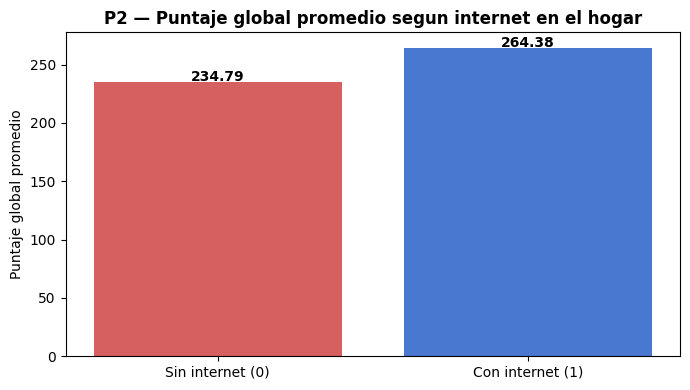

In [9]:
if PLOT_OK:
    d = p2.toPandas()
    etiquetas = ["Sin internet (0)", "Con internet (1)"]
    fig, ax = plt.subplots(figsize=(7, 4))
    ax.bar(etiquetas, d["punt_global_prom"], color=["#D65F5F", "#4878CF"])
    ax.set_title("P2 — Puntaje global promedio segun internet en el hogar",
                 fontweight="bold")
    ax.set_ylabel("Puntaje global promedio")
    for i, v in enumerate(d["punt_global_prom"]):
        ax.text(i, v + 1, str(v), ha="center", fontweight="bold")
    plt.tight_layout()
    plt.show()

---
## Pregunta 3 — ¿Qué tecnologías predominan en municipios con mejor desempeño académico?

**Enfoque:** se calcula el `punt_global` promedio por municipio, se clasifican los municipios en tercil de desempeño (alto/medio/bajo), y se cruza con la `tecnologia` de los accesos de ese municipio. Tabla de contingencia tecnología × nivel de desempeño.

In [10]:
from pyspark.sql import Window

# Desempeno promedio por municipio
desemp_muni = (
    icfes.groupBy("cod_municipio_norm")
         .agg(F.avg("punt_global").alias("punt_global_muni"))
)

# Tercil de desempeno municipal
w = Window.orderBy("punt_global_muni")
desemp_muni = desemp_muni.withColumn("tercil_desemp", F.ntile(3).over(w))
desemp_muni = desemp_muni.withColumn(
    "nivel_desempeno",
    F.when(F.col("tercil_desemp") == 1, "bajo")
     .when(F.col("tercil_desemp") == 2, "medio")
     .otherwise("alto")
)

# Cruce con tecnologia de los accesos del municipio
p3 = (
    internet.join(desemp_muni, on="cod_municipio_norm", how="inner")
            .groupBy("nivel_desempeno", "tecnologia")
            .agg(F.sum("no_de_accesos").alias("total_accesos"))
)

print("PREGUNTA 3 — Tecnologias por nivel de desempeno municipal (top por grupo)")
for nivel in ["alto", "medio", "bajo"]:
    print(f"\n--- Municipios de desempeno {nivel.upper()} ---")
    (p3.filter(F.col("nivel_desempeno") == nivel)
       .orderBy(F.desc("total_accesos"))
       .show(5, truncate=False))

PREGUNTA 3 — Tecnologias por nivel de desempeno municipal (top por grupo)

--- Municipios de desempeno ALTO ---


+---------------+------------------------------+-------------+
|nivel_desempeno|tecnologia                    |total_accesos|
+---------------+------------------------------+-------------+
|alto           |CABLE                         |2257860.0    |
|alto           |XDSL                          |1179012.0    |
|alto           |FIBER TO THE HOME (FTTH)      |1014443.0    |
|alto           |HYBRID FIBER COAXIAL (HFC)    |747152.0     |
|alto           |OTRAS TECNOLOGÍAS INALÁMBRICAS|535074.0     |
+---------------+------------------------------+-------------+
only showing top 5 rows


--- Municipios de desempeno MEDIO ---


+---------------+------------------------------+-------------+
|nivel_desempeno|tecnologia                    |total_accesos|
+---------------+------------------------------+-------------+
|medio          |XDSL                          |579359.0     |
|medio          |CABLE                         |360852.0     |
|medio          |FIBER TO THE HOME (FTTH)      |319173.0     |
|medio          |OTRAS TECNOLOGÍAS INALÁMBRICAS|285715.0     |
|medio          |HYBRID FIBER COAXIAL (HFC)    |151101.0     |
+---------------+------------------------------+-------------+
only showing top 5 rows


--- Municipios de desempeno BAJO ---


+---------------+------------------------------+-------------+
|nivel_desempeno|tecnologia                    |total_accesos|
+---------------+------------------------------+-------------+
|bajo           |XDSL                          |407574.0     |
|bajo           |OTRAS TECNOLOGÍAS INALÁMBRICAS|239333.0     |
|bajo           |SATELITAL                     |140747.0     |
|bajo           |FIBER TO THE HOME (FTTH)      |121150.0     |
|bajo           |CABLE                         |48171.0      |
+---------------+------------------------------+-------------+
only showing top 5 rows



In [11]:
# Cruce adicional: categoria de velocidad por nivel de desempeno
p3_vel = (
    internet.join(desemp_muni, on="cod_municipio_norm", how="inner")
            .filter(F.col("categoria_velocidad_bajada").isNotNull())
            .groupBy("nivel_desempeno", "categoria_velocidad_bajada")
            .agg(F.count("*").alias("n_accesos"))
)
print("PREGUNTA 3 — Categoria de velocidad por nivel de desempeno municipal")
p3_vel.orderBy("nivel_desempeno", F.desc("n_accesos")).show(truncate=False)

PREGUNTA 3 — Categoria de velocidad por nivel de desempeno municipal


[Stage 72:>                                                         (0 + 1) / 1]

+---------------+--------------------------+---------+
|nivel_desempeno|categoria_velocidad_bajada|n_accesos|
+---------------+--------------------------+---------+
|alto           |media                     |456480   |
|alto           |baja                      |303551   |
|alto           |alta                      |231355   |
|bajo           |baja                      |83661    |
|bajo           |media                     |77444    |
|bajo           |alta                      |5374     |
|medio          |media                     |144566   |
|medio          |baja                      |138854   |
|medio          |alta                      |36010    |
+---------------+--------------------------+---------+



basicamente se quiere identificar si las tecnologías de fibra óptica (FTTH) y la categoría de velocidad `alta` se concentran en los municipios de mejor desempeño. La Entrega 1 ya sugería que la fibra se concentra en centros urbanos; esta tabla lo cuantifica frente al desempeño Saber 11.

---
## Pregunta 4 — ¿Cómo varía la brecha oficial vs. no oficial según nivel de conectividad?

**Enfoque:** se cruza `icfes` con el nivel de conectividad municipal y se agrupa por `cole_naturaleza` (OFICIAL / NO OFICIAL) **y** `nivel_conectividad_municipio`. La brecha es la diferencia de puntaje entre tipos de colegio dentro de cada nivel de conectividad.

In [12]:
p4 = (
    icfes_p1
    .filter(
        F.col("nivel_conectividad_municipio").isNotNull()
        & F.col("cole_naturaleza").isin("OFICIAL", "NO OFICIAL")
    )
    .groupBy("nivel_conectividad_municipio", "cole_naturaleza")
    .agg(
        F.count("*").alias("n_estudiantes"),
        F.round(F.avg("punt_global"), 2).alias("punt_global_prom"),
    )
)

# Pivote para ver la brecha lado a lado
p4_pivot = (
    p4.groupBy("nivel_conectividad_municipio")
      .pivot("cole_naturaleza", ["OFICIAL", "NO OFICIAL"])
      .agg(F.first("punt_global_prom"))
      .withColumn("brecha", F.round(F.col("NO OFICIAL") - F.col("OFICIAL"), 2))
      .withColumn("_ord", F.when(F.col("nivel_conectividad_municipio") == "baja", 1)
                            .when(F.col("nivel_conectividad_municipio") == "media", 2)
                            .otherwise(3))
      .orderBy("_ord").drop("_ord")
)

print("PREGUNTA 4 — Brecha oficial vs. no oficial por nivel de conectividad")
print("(brecha = puntaje NO OFICIAL - puntaje OFICIAL)")
p4_pivot.show(truncate=False)

PREGUNTA 4 — Brecha oficial vs. no oficial por nivel de conectividad
(brecha = puntaje NO OFICIAL - puntaje OFICIAL)


[Stage 74:===========================================>              (6 + 2) / 8]

+----------------------------+-------+----------+------+
|nivel_conectividad_municipio|OFICIAL|NO OFICIAL|brecha|
+----------------------------+-------+----------+------+
|baja                        |240.78 |270.75    |29.97 |
|media                       |244.84 |267.56    |22.72 |
|alta                        |249.93 |271.28    |21.35 |
+----------------------------+-------+----------+------+



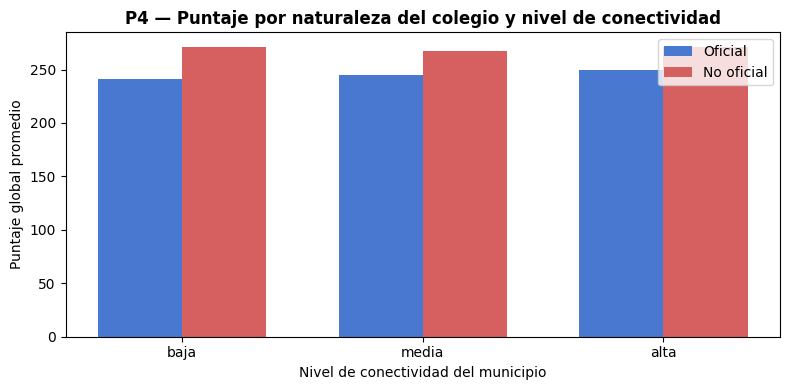

In [13]:
if PLOT_OK:
    d = p4_pivot.toPandas()
    import numpy as np
    x = np.arange(len(d)); width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width/2, d["OFICIAL"], width, label="Oficial", color="#4878CF")
    ax.bar(x + width/2, d["NO OFICIAL"], width, label="No oficial", color="#D65F5F")
    ax.set_title("P4 — Puntaje por naturaleza del colegio y nivel de conectividad",
                 fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(d["nivel_conectividad_municipio"])
    ax.set_xlabel("Nivel de conectividad del municipio")
    ax.set_ylabel("Puntaje global promedio")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Pregunta 5 — ¿Cuál es la relación entre deserción escolar, acceso a internet y resultados ICFES?

**Enfoque:** se trabaja a nivel municipio. Se combina la deserción (`bach`), la conectividad (`municipio`) y el puntaje promedio (`icfes`). Se observa cómo varían la deserción y el puntaje según el nivel de conectividad, y se calculan correlaciones.

In [14]:
# Desercion promedio por municipio
des_muni = (
    bach.filter(F.col("deserci_n").isNotNull())
        .groupBy("cod_municipio_norm")
        .agg(F.avg("deserci_n").alias("desercion_prom"))
)

# Tabla municipal integrada: conectividad + desercion + puntaje
p5 = (
    municipio.select("cod_municipio_norm", "nivel_conectividad_municipio",
                     "accesos_por_habitante")
    .join(des_muni, on="cod_municipio_norm", how="inner")
    .join(desemp_muni.select("cod_municipio_norm", "punt_global_muni"),
          on="cod_municipio_norm", how="inner")
)

resumen_p5 = (
    p5.filter(F.col("nivel_conectividad_municipio").isNotNull())
      .groupBy("nivel_conectividad_municipio")
      .agg(
          F.count("*").alias("n_municipios"),
          F.round(F.avg("desercion_prom"), 2).alias("desercion_prom"),
          F.round(F.avg("punt_global_muni"), 2).alias("punt_global_prom"),
      )
      .withColumn("_ord", F.when(F.col("nivel_conectividad_municipio") == "baja", 1)
                            .when(F.col("nivel_conectividad_municipio") == "media", 2)
                            .otherwise(3))
      .orderBy("_ord").drop("_ord")
)

print("PREGUNTA 5 — Desercion y puntaje por nivel de conectividad municipal")
resumen_p5.show(truncate=False)

c1 = p5.stat.corr("accesos_por_habitante", "desercion_prom")
c2 = p5.stat.corr("accesos_por_habitante", "punt_global_muni")
c3 = p5.stat.corr("desercion_prom", "punt_global_muni")
print(f"\nCorrelacion accesos_por_habitante <-> desercion : {c1:.4f}")
print(f"Correlacion accesos_por_habitante <-> puntaje    : {c2:.4f}")
print(f"Correlacion desercion <-> puntaje                : {c3:.4f}")

PREGUNTA 5 — Desercion y puntaje por nivel de conectividad municipal
+----------------------------+------------+--------------+----------------+
|nivel_conectividad_municipio|n_municipios|desercion_prom|punt_global_prom|
+----------------------------+------------+--------------+----------------+
|baja                        |2443        |3.47          |231.05          |
|media                       |2400        |3.42          |240.16          |
|alta                        |2589        |3.49          |246.33          |
+----------------------------+------------+--------------+----------------+




Correlacion accesos_por_habitante <-> desercion : 0.0124
Correlacion accesos_por_habitante <-> puntaje    : 0.0228
Correlacion desercion <-> puntaje                : -0.1875


---
## Pregunta 6 — ¿Qué porcentaje de sedes tiene internet y cómo se relaciona con la cobertura neta?

**Enfoque:** se usa la tabla `bach`. La columna `sedes_conectadas_a_internet` se relaciona con `cobertura_neta`. Se analiza la correlación y se compara la cobertura neta entre municipios con alta y baja conexión de sedes.

*Nota: `sedes_conectadas_a_internet` tenía ~50% de nulos según la Entrega 1; el análisis se limita a registros no nulos.*

In [15]:
p6_base = bach.filter(
    F.col("sedes_conectadas_a_internet").isNotNull()
    & F.col("cobertura_neta").isNotNull()
)

n_total = bach.count()
n_con_dato = p6_base.count()
print("PREGUNTA 6 — Sedes conectadas a internet y cobertura neta")
print(f"  Registros con dato de sedes conectadas: {n_con_dato:,} de {n_total:,} "
      f"({100*n_con_dato/n_total:.1f}%)")

# Correlacion sedes conectadas <-> cobertura neta
corr_p6 = p6_base.stat.corr("sedes_conectadas_a_internet", "cobertura_neta")
print(f"  Correlacion (sedes_conectadas_a_internet, cobertura_neta): {corr_p6:.4f}")

# Comparacion: cobertura neta segun mediana de sedes conectadas
mediana = p6_base.approxQuantile("sedes_conectadas_a_internet", [0.5], 0.01)[0]
p6 = (
    p6_base
    .withColumn("grupo_sedes",
                F.when(F.col("sedes_conectadas_a_internet") >= mediana,
                       "alta conexion de sedes")
                 .otherwise("baja conexion de sedes"))
    .groupBy("grupo_sedes")
    .agg(
        F.count("*").alias("n_municipios"),
        F.round(F.avg("cobertura_neta"), 2).alias("cobertura_neta_prom"),
    )
)
print(f"\n  (mediana de sedes conectadas usada como corte: {mediana})")
p6.show(truncate=False)

PREGUNTA 6 — Sedes conectadas a internet y cobertura neta
  Registros con dato de sedes conectadas: 7,768 de 15,707 (49.5%)
  Correlacion (sedes_conectadas_a_internet, cobertura_neta): 0.1425

  (mediana de sedes conectadas usada como corte: 27.59)
+----------------------+------------+-------------------+
|grupo_sedes           |n_municipios|cobertura_neta_prom|
+----------------------+------------+-------------------+
|baja conexion de sedes|3836        |82.85              |
|alta conexion de sedes|3932        |87.25              |
+----------------------+------------+-------------------+



---
## Pregunta 7 — ¿En qué áreas del conocimiento es mayor la brecha entre municipios conectados y no conectados?

**Enfoque:** para cada una de las 5 áreas (`punt_matematicas`, `punt_lectura_critica`, `punt_c_naturales`, `punt_sociales_ciudadanas`, `punt_ingles`) se calcula el promedio en municipios de conectividad `alta` vs. `baja`. La brecha por área es la diferencia entre ambos.

**ADVERTENCIA IMPORTANTE:** `punt_ingles` fue **imputado por la media** en el Punto 1. Su varianza está artificialmente reducida, por lo que la brecha de inglés aparecerá comprimida y **no es comparable en igualdad de condiciones** con las otras áreas.

In [20]:
areas = [
    "punt_matematicas", "punt_lectura_critica", "punt_c_naturales",
    "punt_sociales_ciudadanas", "punt_ingles",
]

p7_aggs = [F.round(F.avg(c), 2).alias(c) for c in areas]

p7 = (
    icfes_p1
    .filter(F.col("nivel_conectividad_municipio").isin("alta", "baja"))
    .groupBy("nivel_conectividad_municipio")
    .agg(*p7_aggs)
)

print("PREGUNTA 7 — Puntaje promedio por area y nivel de conectividad")
p7.show(truncate=False)

# Brecha por area (alta - baja). Se calcula en pandas para presentar ordenado.
d7 = p7.toPandas().set_index("nivel_conectividad_municipio")
print("\nBrecha por area (puntaje conectividad ALTA - puntaje conectividad BAJA):")
if "alta" in d7.index and "baja" in d7.index:
    brechas = []
    for c in areas:
        diff = round(float(d7.loc["alta", c]) - float(d7.loc["baja", c]), 2)
        brechas.append((c, diff))
    for c, diff in sorted(brechas, key=lambda x: -x[1]):
        marca = "  <- imputada por la media" \
                if c == "punt_ingles" else ""
        print(f"  {c:<26}: {diff:+6.2f}{marca}")
else:
    print("  No hay datos suficientes en ambos niveles para calcular la brecha.")

PREGUNTA 7 — Puntaje promedio por area y nivel de conectividad


+----------------------------+----------------+--------------------+----------------+------------------------+-----------+
|nivel_conectividad_municipio|punt_matematicas|punt_lectura_critica|punt_c_naturales|punt_sociales_ciudadanas|punt_ingles|
+----------------------------+----------------+--------------------+----------------+------------------------+-----------+
|baja                        |48.78           |51.67               |49.52           |48.35                   |48.41      |
|alta                        |49.82           |52.73               |50.63           |49.43                   |48.84      |
+----------------------------+----------------+--------------------+----------------+------------------------+-----------+



[Stage 174:=================================================>       (7 + 1) / 8]


Brecha por area (puntaje conectividad ALTA - puntaje conectividad BAJA):
  punt_c_naturales          :  +1.11
  punt_sociales_ciudadanas  :  +1.08
  punt_lectura_critica      :  +1.06
  punt_matematicas          :  +1.04
  punt_ingles               :  +0.43  <- imputada por la media


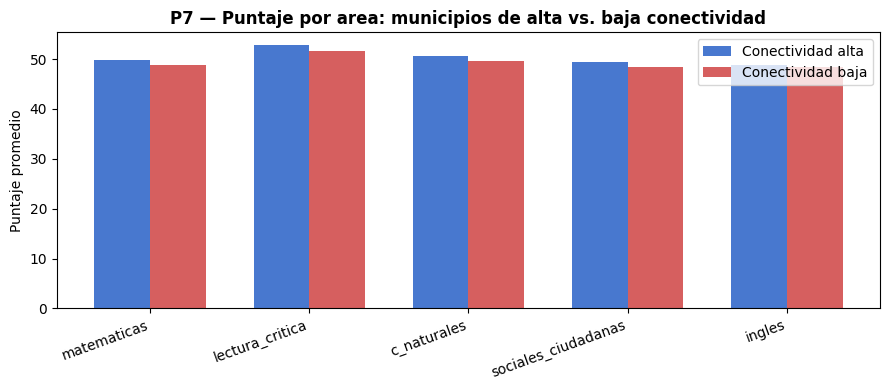

In [17]:
if PLOT_OK and "alta" in d7.index and "baja" in d7.index:
    import numpy as np
    nombres = [a.replace("punt_", "") for a in areas]
    x = np.arange(len(areas)); width = 0.35
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(x - width/2, [d7.loc["alta", a] for a in areas], width,
           label="Conectividad alta", color="#4878CF")
    ax.bar(x + width/2, [d7.loc["baja", a] for a in areas], width,
           label="Conectividad baja", color="#D65F5F")
    ax.set_title("P7 — Puntaje por area: municipios de alta vs. baja conectividad",
                 fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(nombres, rotation=20, ha="right")
    ax.set_ylabel("Puntaje promedio")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Pregunta 8 — ¿Existe diferencia urbano/rural en Saber 11 y cómo interactúa con el acceso a internet?

**Enfoque:** se agrupa `icfes` por `cole_area_ubicacion` (URBANO / RURAL) y `flag_internet_hogar`. La tabla resultante muestra el efecto combinado de la zona del colegio y el acceso doméstico a internet sobre el puntaje.

In [18]:
p8 = (
    icfes
    .filter(
        F.col("cole_area_ubicacion").isin("URBANO", "RURAL")
        & F.col("flag_internet_hogar").isNotNull()
    )
    .groupBy("cole_area_ubicacion", "flag_internet_hogar")
    .agg(
        F.count("*").alias("n_estudiantes"),
        F.round(F.avg("punt_global"), 2).alias("punt_global_prom"),
    )
    .orderBy("cole_area_ubicacion", "flag_internet_hogar")
)

print("PREGUNTA 8 — Puntaje por zona del colegio e internet en el hogar")
p8.show(truncate=False)

# Brecha urbano-rural global (sin condicionar por internet)
p8_zona = (
    icfes.filter(F.col("cole_area_ubicacion").isin("URBANO", "RURAL"))
         .groupBy("cole_area_ubicacion")
         .agg(F.round(F.avg("punt_global"), 2).alias("punt_global_prom"))
)
print("\nBrecha urbano-rural global:")
p8_zona.show(truncate=False)

PREGUNTA 8 — Puntaje por zona del colegio e internet en el hogar
+-------------------+-------------------+-------------+----------------+
|cole_area_ubicacion|flag_internet_hogar|n_estudiantes|punt_global_prom|
+-------------------+-------------------+-------------+----------------+
|RURAL              |0                  |712012       |225.74          |
|RURAL              |1                  |254863       |254.7           |
|URBANO             |0                  |2467504      |238.12          |
|URBANO             |1                  |3460726      |265.17          |
+-------------------+-------------------+-------------+----------------+


Brecha urbano-rural global:
+-------------------+----------------+
|cole_area_ubicacion|punt_global_prom|
+-------------------+----------------+
|RURAL              |233.5           |
|URBANO             |255.1           |
+-------------------+----------------+



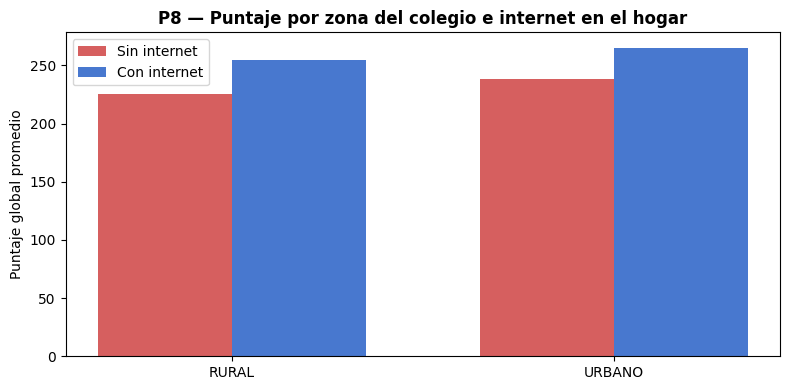

In [19]:
if PLOT_OK:
    d = p8.toPandas()
    import numpy as np
    zonas = ["RURAL", "URBANO"]
    sin_net = [float(d[(d.cole_area_ubicacion == z) &
                       (d.flag_internet_hogar == 0)]["punt_global_prom"].iloc[0])
               if not d[(d.cole_area_ubicacion == z) &
                        (d.flag_internet_hogar == 0)].empty else 0
               for z in zonas]
    con_net = [float(d[(d.cole_area_ubicacion == z) &
                       (d.flag_internet_hogar == 1)]["punt_global_prom"].iloc[0])
               if not d[(d.cole_area_ubicacion == z) &
                        (d.flag_internet_hogar == 1)].empty else 0
               for z in zonas]
    x = np.arange(len(zonas)); width = 0.35
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.bar(x - width/2, sin_net, width, label="Sin internet", color="#D65F5F")
    ax.bar(x + width/2, con_net, width, label="Con internet", color="#4878CF")
    ax.set_title("P8 — Puntaje por zona del colegio e internet en el hogar",
                 fontweight="bold")
    ax.set_xticks(x); ax.set_xticklabels(zonas)
    ax.set_ylabel("Puntaje global promedio")
    ax.legend()
    plt.tight_layout()
    plt.show()

---
## Síntesis — Hallazgos del Punto 2 y conexión con el modelado

Las 8 preguntas anteriores entregan la evidencia descriptiva que sustenta la pregunta central del proyecto: *en qué medida el acceso a internet municipal se relaciona con los resultados Saber 11*.

**Variables que el análisis confirma como relevantes para el modelado (Punto 5):**

- `flag_internet_hogar` — asociación directa con el puntaje (P2, P8).
- `nivel_conectividad_municipio` / `accesos_por_habitante` — gradiente de desempeño territorial (P1, P4, P5, P7).
- `cole_naturaleza` — la brecha oficial/no oficial interactúa con la conectividad (P4).
- `cole_area_ubicacion` — la brecha urbano/rural interactúa con el internet doméstico (P8).
- `deserci_n`, `cobertura_neta` — variables de control del contexto educativo (P5, P6).

**Limitaciones a declarar en el informe:**

1. Las correlaciones no implican causalidad; el estrato socioeconómico es una variable de confusión no incluida en estas tablas (sí debe entrar al modelado).
2. `punt_ingles` está imputado por la media — su brecha (P7) está subestimada.
3. `punt_global` está filtrado por IQR — los promedios excluyen outliers.
4. `sedes_conectadas_a_internet` tiene ~50% de nulos (P6).

Estos hallazgos alimentan directamente la selección de *features* del modelo supervisado y la definición de los clústeres de municipios del modelo no supervisado.

## Puente con el modelado (Puntos 5-6) — Importancia de variables
 
Las 8 preguntas anteriores son **análisis descriptivo**: muestran asociaciones
(internet ↔ puntaje, conectividad ↔ desempeño) pero no pueden separar el efecto
del internet del efecto de otras variables que lo acompañan — sobre todo el
**estrato socioeconómico**. 
 
Esta sección cierra ese vacío con un **modelo exploratorio mínimo**: un Random
Forest de MLlib que estima la **importancia relativa de cada variable** al
predecir el puntaje global. El objetivo no es entrenar un modelo de producción
—ese es el trabajo de los Puntos 5-6 (`ml_train.py` con XGBoost y
`ml_profiling.py` con K-Means + Random Forest)— sino **verificar la hipótesis**
de que el estrato pesa más que el internet.
 
Relación entre los notebooks del proyecto:
 
| Notebook | Rol | Modelo |
|---|---|---|
| Este (Punto 2) | Análisis descriptivo + verificación exploratoria | Random Forest mínimo (MLlib) |
| `ml_algorithms.ipynb` (Puntos 5-6) | Modelado completo de producción | XGBoost + K-Means + Random Forest |
 
La celda siguiente lee el **Parquet ICFES crudo** (no la tabla limpia) porque
necesita `fami_estratovivienda` y la educación de los padres, columnas que el
pipeline del Punto 1 no arrastra a la tabla limpia. Usa únicamente `pyspark.ml`
—sin XGBoost ni dependencias externas— y entrena sobre una muestra para ser
rápida y no saturar el clúster.

In [22]:
# ── Random Forest exploratorio: importancia de variables ──
# MLlib puro. Lee el Parquet ICFES CRUDO para incluir variables socioeconomicas
# (estrato, educacion de padres) que la tabla limpia del Punto 1 no contiene.
 
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, VectorAssembler, Imputer
from pyspark.ml.regression import RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator
 
RAW = "hdfs://spark-master:9000/data/parquet"
MUESTRA_RF = 50000  # filas de muestra; sube/baja segun disponibilidad del cluster
 
# Variables socioeconomicas candidatas (mismas que ml_profiling.py del companero).
# Se filtran a las que existan realmente en el Parquet crudo.
cat_candidatas = [
    "fami_estratovivienda", "fami_educacionmadre", "fami_educacionpadre",
    "fami_tieneinternet", "fami_tienecomputador", "fami_tieneautomovil",
    "cole_naturaleza", "cole_area_ubicacion",
]
 
icfes_raw = spark.read.parquet(f"{RAW}/icfes")
 
# Solo columnas presentes (patron defensivo: no se rompe si falta alguna)
cat_feats = [c for c in cat_candidatas if c in icfes_raw.columns]
print("Variables categoricas usadas:", cat_feats)
 
# Dataset de muestra con target valido
df_rf = (
    icfes_raw
    .select(*cat_feats, "punt_global")
    .withColumn("punt_global", F.col("punt_global").cast("double"))
    .filter(F.col("punt_global").isNotNull()
            & (F.col("punt_global") >= 0) & (F.col("punt_global") <= 500))
    .orderBy(F.rand(42))
    .limit(MUESTRA_RF)
)
print(f"Filas de muestra para el Random Forest: {df_rf.count():,}")
 
# Pipeline MLlib: indexar categoricas -> ensamblar -> Random Forest
indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in cat_feats
]
assembler = VectorAssembler(
    inputCols=[f"{c}_idx" for c in cat_feats],
    outputCol="features", handleInvalid="keep",
)
rf = RandomForestRegressor(
    featuresCol="features", labelCol="punt_global",
    numTrees=30, maxDepth=6, seed=42,
)
pipeline = Pipeline(stages=indexers + [assembler, rf])
 
# Entrenar (80/20) y evaluar
train_df, test_df = df_rf.randomSplit([0.8, 0.2], seed=42)
modelo_rf = pipeline.fit(train_df)
pred = modelo_rf.transform(test_df)
 
r2 = RegressionEvaluator(labelCol="punt_global", predictionCol="prediction",
                         metricName="r2").evaluate(pred)
rmse = RegressionEvaluator(labelCol="punt_global", predictionCol="prediction",
                           metricName="rmse").evaluate(pred)
print(f"\nMetricas del modelo exploratorio  ->  R2: {r2:.3f} | RMSE: {rmse:.2f}")
 
# Tabla de importancia de variables
importancias = modelo_rf.stages[-1].featureImportances.toArray()
tabla_imp = sorted(zip(cat_feats, importancias), key=lambda x: -x[1])
 
print("\nIMPORTANCIA DE VARIABLES (Random Forest, prediccion de punt_global):")
print(f"{'variable':<26} {'importancia':>12}")
print("-" * 40)
for var, imp in tabla_imp:
    marca = "  <- acceso a internet" if var in (
        "fami_tieneinternet",) else ""
    print(f"{var:<26} {imp:>12.4f}{marca}")

Variables categoricas usadas: ['fami_estratovivienda', 'fami_educacionmadre', 'fami_educacionpadre', 'fami_tieneinternet', 'fami_tienecomputador', 'fami_tieneautomovil', 'cole_naturaleza', 'cole_area_ubicacion']


Filas de muestra para el Random Forest: 50,000


[Stage 221:>                                                        (0 + 1) / 1]


Metricas del modelo exploratorio  ->  R2: 0.265 | RMSE: 43.54

IMPORTANCIA DE VARIABLES (Random Forest, prediccion de punt_global):
variable                    importancia
----------------------------------------
fami_educacionmadre              0.3551
fami_educacionpadre              0.1872
fami_tieneinternet               0.1362  <- acceso a internet
fami_tienecomputador             0.1138
fami_estratovivienda             0.0991
cole_naturaleza                  0.0661
fami_tieneautomovil              0.0256
cole_area_ubicacion              0.0169


 
**Lectura del modelo exploratorio.**
 
La tabla de importancia ordena las variables por su peso al predecir el puntaje
global. La lectura esperada —y que valida las advertencias de las preguntas 2,
5 y 8— es que la educación de los padres encabecen la
lista**, por encima de `fami_tieneinternet`.
 
se confirma lo que el análisis descriptivo solo podía
sugerir: el internet del hogar **está correlacionado** con el puntaje, pero buena
parte de ese efecto lo explica el nivel socioeconómico de la familia. El internet
actúa en parte como *proxy* del estrato. Esto NO anula los hallazgos del Punto 2
—la conectividad sigue importando, sobre todo para cerrar la brecha urbano-rural
(Pregunta 8)— pero los pone en su justa dimensión.
 
**Limitaciones de esta celda** (declararlas en el informe):
- Es un modelo **exploratorio** sobre una muestra de 50.000 filas, no de producción.
- Usa solo variables categóricas indexadas; el modelado completo (Punto 5-6)
  incorpora además variables municipales y un tratamiento más fino.
- El `R²` será modesto: con solo estas variables no se predice el puntaje con
  precisión — el objetivo aquí es **comparar pesos relativos**, no predecir bien.
 
El modelado riguroso —XGBoost para predicción y K-Means para perfilamiento— se
desarrolla en `ml_algorithms.ipynb` (Puntos 5-6).